In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

In [2]:
csv_path = "foia-7a-fy2010-fy2019-asof-260331.csv"
dict_path = "7a_504_foia_data_dictionary-asof-260331.xlsx"

In [4]:
cols = pd.read_csv(csv_path, nrows=0).columns.tolist()

cols

['asofdate',
 'program',
 'locationid',
 'borrname',
 'borrstreet',
 'borrcity',
 'borrstate',
 'borrzip',
 'bankname',
 'bankfdicnumber',
 'bankncuanumber',
 'bankstreet',
 'bankcity',
 'bankstate',
 'bankzip',
 'grossapproval',
 'sbaguaranteedapproval',
 'approvaldate',
 'approvalfy',
 'firstdisbursementdate',
 'processingmethod',
 'subprogram',
 'initialinterestrate',
 'fixedorvariableinterestind',
 'terminmonths',
 'naicscode',
 'naicsdescription',
 'franchisecode',
 'franchisename',
 'projectcounty',
 'projectstate',
 'sbadistrictoffice',
 'congressionaldistrict',
 'businesstype',
 'businessage',
 'loanstatus',
 'paidinfulldate',
 'chargeoffdate',
 'grosschargeoffamount',
 'revolverstatus',
 'jobssupported',
 'collateralind',
 'soldsecmrktind']

In [5]:
usecols = [
    "borrstate",
    "bankstate",
    "approvalfy",
    "processingmethod",
    "subprogram",
    "initialinterestrate",
    "fixedorvariableinterestind",
    "terminmonths",
    "naicscode",
    "naicsdescription",
    "projectstate",
    "businesstype",
    "businessage",
    "loanstatus",
    "grossapproval",
    "sbaguaranteedapproval",
    "jobssupported",
    "collateralind",
    "soldsecmrktind"
]

df = pd.read_csv(
    csv_path,
    usecols=usecols,
    low_memory=False
)

df.shape

(545751, 19)

In [6]:
df["loanstatus"].value_counts(dropna=False)

loanstatus
P I F             391693
CANCLD             66740
CURR               44482
CHGOFF             30849
PURCH(NOT C/O)      4703
CLSLN               2835
LIQUID              2667
DELINQ              1069
PSTDUE               547
DEFERD               116
COMMIT                49
SOLDNC                 1
Name: count, dtype: int64

In [7]:
df_model = df[df["loanstatus"].isin(["P I F", "CHGOFF"])].copy()

df_model["default"] = np.where(df_model["loanstatus"] == "CHGOFF", 1, 0)

df_model["default"].value_counts()

default
0    391693
1     30849
Name: count, dtype: int64

In [8]:
df_model["default"].mean()

np.float64(0.0730081270027595)

In [9]:
df_model["sba_guarantee_pct"] = (
    df_model["sbaguaranteedapproval"] / df_model["grossapproval"]
)

df_model["log_grossapproval"] = np.log1p(df_model["grossapproval"])
df_model["log_sbaguaranteedapproval"] = np.log1p(df_model["sbaguaranteedapproval"])

df_model["naics_2d"] = (
    df_model["naicscode"]
    .astype("Int64")
    .astype(str)
    .str[:2]
)

In [10]:
features = [
    "borrstate",
    "bankstate",
    "processingmethod",
    "subprogram",
    "initialinterestrate",
    "fixedorvariableinterestind",
    "terminmonths",
    "naics_2d",
    "projectstate",
    "businesstype",
    "businessage",
    "log_grossapproval",
    "log_sbaguaranteedapproval",
    "sba_guarantee_pct",
    "jobssupported",
    "collateralind",
    "soldsecmrktind"
]

target = "default"

df_ml = df_model[features + [target, "approvalfy"]].copy()

df_ml.shape

(422542, 19)

In [11]:
train = df_ml[df_ml["approvalfy"] <= 2017].copy()
test = df_ml[df_ml["approvalfy"] >= 2018].copy()

train.shape, test.shape

((350403, 19), (72139, 19))

In [12]:
print("Default train:", train[target].mean())
print("Default test:", test[target].mean())

Default train: 0.06819005545043849
Default test: 0.09641109524667656


In [16]:
from sklearn.model_selection import train_test_split

# Tamaño máximo de muestra para entrenar rápido
n_sample = min(120000, len(train))

# Muestra estratificada: mantiene proporción de default/no default
train_sample, _ = train_test_split(
    train,
    train_size=n_sample,
    random_state=42,
    stratify=train[target]
)

test_sample = test.copy()

train_sample.shape, test_sample.shape

((120000, 19), (72139, 19))

In [17]:
print("Default train original:", train[target].mean())
print("Default train sample:", train_sample[target].mean())
print("Default test:", test_sample[target].mean())

Default train original: 0.06819005545043849
Default train sample: 0.06819166666666666
Default test: 0.09641109524667656


In [18]:
X_train = train_sample[features]
y_train = train_sample[target]

X_test = test_sample[features]
y_test = test_sample[target]

categorical_features = X_train.select_dtypes(include=["object", "bool"]).columns.tolist()
numeric_features = [c for c in features if c not in categorical_features]

print("Variables categóricas:")
print(categorical_features)

print("\nVariables numéricas:")
print(numeric_features)

Variables categóricas:
['borrstate', 'bankstate', 'processingmethod', 'subprogram', 'fixedorvariableinterestind', 'naics_2d', 'projectstate', 'businesstype', 'businessage', 'collateralind', 'soldsecmrktind']

Variables numéricas:
['initialinterestrate', 'terminmonths', 'log_grossapproval', 'log_sbaguaranteedapproval', 'sba_guarantee_pct', 'jobssupported']


In [19]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        min_samples_leaf=200,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

proba_rf = rf_model.predict_proba(X_test)[:, 1]

auc_rf = roc_auc_score(y_test, proba_rf)

auc_rf

0.8862961358381799

In [21]:
test_result = test_sample.copy()
test_result["score_riesgo"] = proba_rf

test_result["decil_riesgo"] = pd.qcut(
    test_result["score_riesgo"],
    10,
    labels=False,
    duplicates="drop"
) + 1

tabla_deciles = test_result.groupby("decil_riesgo").agg(
    n=("default", "count"),
    tasa_default=("default", "mean"),
    score_promedio=("score_riesgo", "mean")
).reset_index()

tabla_deciles

,decil_riesgo,n,tasa_default,score_promedio
0,1,7214,0.004574,0.320308
1,2,7214,0.006654,0.358322
2,3,7214,0.017466,0.374109
3,4,7214,0.024258,0.388905
4,5,7214,0.035764,0.404698
5,6,7213,0.035491,0.420921
6,7,7214,0.014832,0.443308
7,8,7214,0.041309,0.472341
8,9,7214,0.226920,0.540808
9,10,7214,0.556834,0.638165


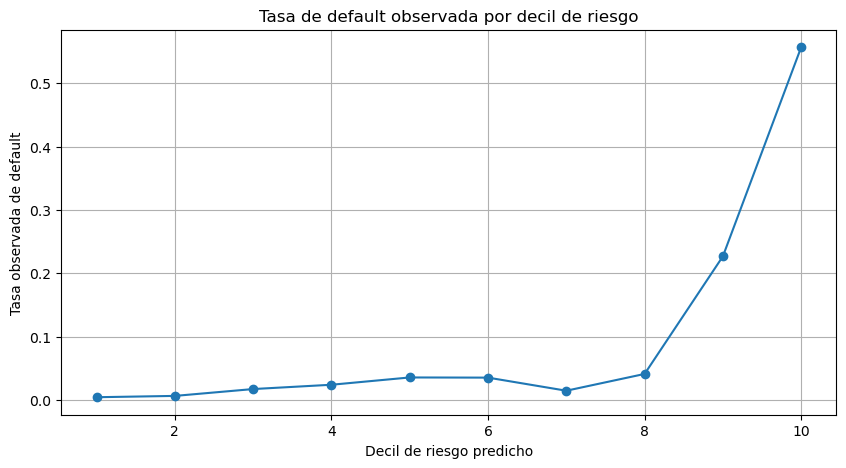

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    tabla_deciles["decil_riesgo"],
    tabla_deciles["tasa_default"],
    marker="o"
)

plt.xlabel("Decil de riesgo predicho")
plt.ylabel("Tasa observada de default")
plt.title("Tasa de default observada por decil de riesgo")
plt.grid(True)
plt.show()

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

# Preprocesamiento específico para Logit:
# la regresión logística necesita variables numéricas escaladas
numeric_transformer_logit = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer_logit = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_logit = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_logit, numeric_features),
        ("cat", categorical_transformer_logit, categorical_features)
    ]
)

logit_model = Pipeline(steps=[
    ("preprocessor", preprocessor_logit),
    ("model", LogisticRegression(
        max_iter=5000,
        solver="saga",
        penalty="l2",
        class_weight="balanced",
        n_jobs=-1,
        random_state=42
    ))
])

logit_model.fit(X_train, y_train)

proba_logit = logit_model.predict_proba(X_test)[:, 1]

auc_logit = roc_auc_score(y_test, proba_logit)

auc_logit

0.8388511737563911

In [27]:
comparacion_auc = pd.DataFrame({
    "modelo": ["Regresión logística", "Random Forest"],
    "AUC": [auc_logit, auc_rf]
})

comparacion_auc

,modelo,AUC
0,Regresión logística,0.838851
1,Random Forest,0.886296


In [28]:
def curva_inclusion(y_real, score, nombre_modelo):
    temp = pd.DataFrame({
        "default": y_real.values,
        "score_riesgo": score
    }).sort_values("score_riesgo", ascending=True).reset_index(drop=True)
    
    temp["n_acum"] = np.arange(1, len(temp) + 1)
    temp["pct_incluido"] = temp["n_acum"] / len(temp)
    temp["defaults_acum"] = temp["default"].cumsum()
    temp["tasa_default_acum"] = temp["defaults_acum"] / temp["n_acum"]
    temp["modelo"] = nombre_modelo
    
    return temp

curva_logit = curva_inclusion(y_test, proba_logit, "Regresión logística")
curva_rf = curva_inclusion(y_test, proba_rf, "Random Forest")

curvas = pd.concat([curva_logit, curva_rf], ignore_index=True)

curvas.head()

,default,score_riesgo,n_acum,pct_incluido,defaults_acum,tasa_default_acum,modelo
0,0,0.000109,1,0.000014,0,0.0,Regresión logística
1,0,0.000219,2,0.000028,0,0.0,Regresión logística
2,0,0.000222,3,0.000042,0,0.0,Regresión logística
3,0,0.000223,4,0.000055,0,0.0,Regresión logística
4,0,0.000234,5,0.000069,0,0.0,Regresión logística


In [29]:
puntos = np.arange(0.1, 1.01, 0.1)

resumen_curvas = []

for modelo, data in curvas.groupby("modelo"):
    for p in puntos:
        fila = data[data["pct_incluido"] <= p].tail(1)
        if len(fila) > 0:
            resumen_curvas.append({
                "modelo": modelo,
                "pct_incluido": p,
                "tasa_default_acum": fila["tasa_default_acum"].values[0]
            })

resumen_curvas = pd.DataFrame(resumen_curvas)

resumen_curvas

,modelo,pct_incluido,tasa_default_acum
0,Random Forest,0.1,0.004575
1,Random Forest,0.2,0.005614
2,Random Forest,0.3,0.009565
3,Random Forest,0.4,0.013239
4,Random Forest,0.5,0.017744
5,Random Forest,0.6,0.020701
6,Random Forest,0.7,0.019863
7,Random Forest,0.8,0.022543
8,Random Forest,0.9,0.045252
9,Random Forest,1.0,0.096411


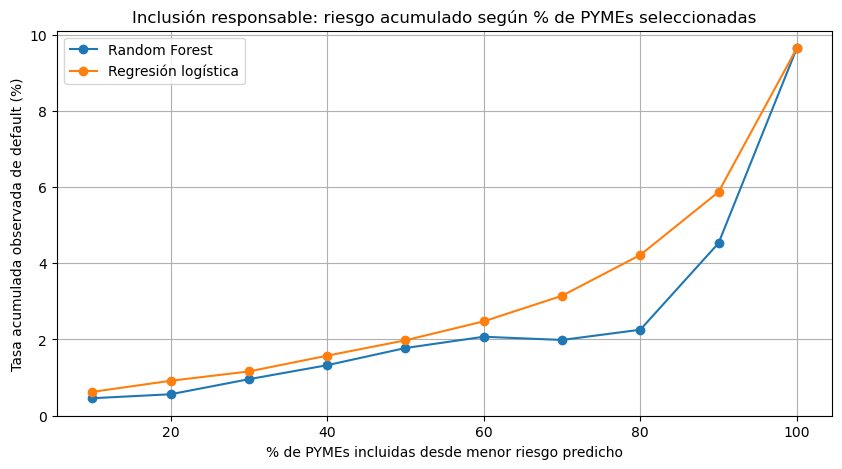

In [30]:
plt.figure(figsize=(10, 5))

for modelo in resumen_curvas["modelo"].unique():
    data = resumen_curvas[resumen_curvas["modelo"] == modelo]
    plt.plot(
        data["pct_incluido"] * 100,
        data["tasa_default_acum"] * 100,
        marker="o",
        label=modelo
    )

plt.xlabel("% de PYMEs incluidas desde menor riesgo predicho")
plt.ylabel("Tasa acumulada observada de default (%)")
plt.title("Inclusión responsable: riesgo acumulado según % de PYMEs seleccionadas")
plt.legend()
plt.grid(True)
plt.show()

In [31]:
umbrales_riesgo = [0.03, 0.05, 0.07, 0.10]

resultados_inclusion = []

for modelo, data in curvas.groupby("modelo"):
    for umbral in umbrales_riesgo:
        elegibles = data[data["tasa_default_acum"] <= umbral]
        
        if len(elegibles) > 0:
            max_pct = elegibles["pct_incluido"].max()
            n_incluidos = elegibles["n_acum"].max()
        else:
            max_pct = 0
            n_incluidos = 0
        
        resultados_inclusion.append({
            "modelo": modelo,
            "riesgo_maximo_default": umbral,
            "pct_pymes_incluidas": max_pct,
            "n_pymes_incluidas": n_incluidos
        })

resultados_inclusion = pd.DataFrame(resultados_inclusion)

resultados_inclusion

,modelo,riesgo_maximo_default,pct_pymes_incluidas,n_pymes_incluidas
0,Random Forest,0.03,0.844869,60948
1,Random Forest,0.05,0.909605,65618
2,Random Forest,0.07,0.956778,69021
3,Random Forest,0.10,1.000000,72139
4,Regresión logística,0.03,0.675890,48758
5,Regresión logística,0.05,0.851620,61435
6,Regresión logística,0.07,0.946728,68296
7,Regresión logística,0.10,1.000000,72139


In [32]:
tabla_inclusion = resultados_inclusion.pivot(
    index="riesgo_maximo_default",
    columns="modelo",
    values="pct_pymes_incluidas"
).reset_index()

tabla_inclusion["ganancia_rf_vs_logit_pp"] = (
    tabla_inclusion["Random Forest"] - tabla_inclusion["Regresión logística"]
) * 100

tabla_inclusion["riesgo_maximo_default"] = tabla_inclusion["riesgo_maximo_default"] * 100
tabla_inclusion["Regresión logística"] = tabla_inclusion["Regresión logística"] * 100
tabla_inclusion["Random Forest"] = tabla_inclusion["Random Forest"] * 100

tabla_inclusion

modelo,riesgo_maximo_default,Random Forest,Regresión logística,ganancia_rf_vs_logit_pp
0,3.0,84.486893,67.588960,16.897933
1,5.0,90.960507,85.161979,5.798528
2,7.0,95.677789,94.672784,1.005004
3,10.0,100.000000,100.000000,0.000000


In [34]:
pct_seleccion = 0.40

test_comp = test_sample.copy()
test_comp["score_logit"] = proba_logit
test_comp["score_rf"] = proba_rf

cut_logit = test_comp["score_logit"].quantile(pct_seleccion)
cut_rf = test_comp["score_rf"].quantile(pct_seleccion)

test_comp["seleccion_logit"] = test_comp["score_logit"] <= cut_logit
test_comp["seleccion_rf"] = test_comp["score_rf"] <= cut_rf

condiciones = [
    (test_comp["seleccion_logit"]) & (test_comp["seleccion_rf"]),
    (test_comp["seleccion_logit"]) & (~test_comp["seleccion_rf"]),
    (~test_comp["seleccion_logit"]) & (test_comp["seleccion_rf"]),
    (~test_comp["seleccion_logit"]) & (~test_comp["seleccion_rf"]),
]

opciones = [
    "Seleccionado por ambos",
    "Solo Logit",
    "Solo Random Forest",
    "No seleccionado"
]

test_comp["grupo"] = np.select(
    condiciones,
    opciones,
    default="Sin clasificar"
)

resumen_grupos = test_comp.groupby("grupo").agg(
    n=("default", "count"),
    tasa_default=("default", "mean"),
    score_logit_prom=("score_logit", "mean"),
    score_rf_prom=("score_rf", "mean")
).reset_index()

resumen_grupos

,grupo,n,tasa_default,score_logit_prom,score_rf_prom
0,No seleccionado,31593,0.198462,0.748042,0.504228
1,Seleccionado por ambos,17166,0.008796,0.207840,0.354184
2,Solo Logit,11690,0.025920,0.180318,0.439359
3,Solo Random Forest,11690,0.019760,0.622319,0.369554


In [35]:
resumen_grupos["tasa_default_pct"] = resumen_grupos["tasa_default"] * 100
resumen_grupos["participacion_pct"] = resumen_grupos["n"] / resumen_grupos["n"].sum() * 100

resumen_grupos.sort_values("grupo")

,grupo,n,tasa_default,score_logit_prom,score_rf_prom,tasa_default_pct,participacion_pct
0,No seleccionado,31593,0.198462,0.748042,0.504228,19.846168,43.794619
1,Seleccionado por ambos,17166,0.008796,0.207840,0.354184,0.879646,23.795728
2,Solo Logit,11690,0.025920,0.180318,0.439359,2.591959,16.204827
3,Solo Random Forest,11690,0.019760,0.622319,0.369554,1.976048,16.204827


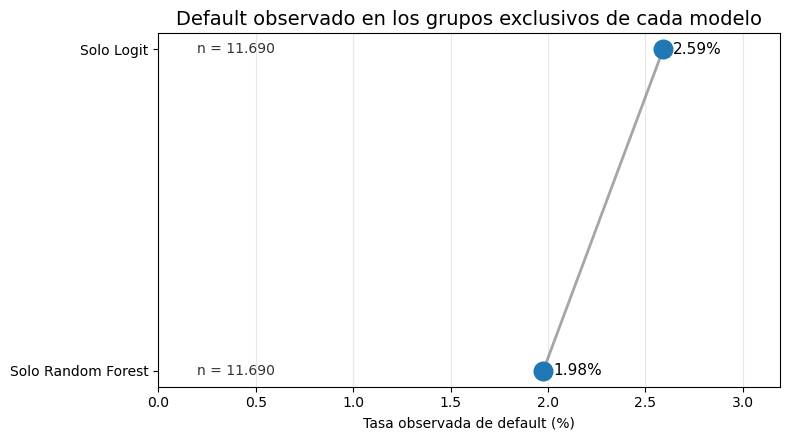

In [36]:
import pandas as pd
import matplotlib.pyplot as plt

# Filtrar solo los grupos más interesantes
plot_df = resumen_grupos[resumen_grupos["grupo"].isin(["Solo Logit", "Solo Random Forest"])].copy()

plot_df["tasa_default_pct"] = plot_df["tasa_default"] * 100

# Orden visual
orden = ["Solo Random Forest", "Solo Logit"]
plot_df["grupo"] = pd.Categorical(plot_df["grupo"], categories=orden, ordered=True)
plot_df = plot_df.sort_values("grupo")

fig, ax = plt.subplots(figsize=(8, 4.5))

# Línea que une ambos puntos
ax.plot(
    plot_df["tasa_default_pct"],
    plot_df["grupo"],
    color="gray",
    linewidth=2,
    alpha=0.7
)

# Puntos
ax.scatter(
    plot_df["tasa_default_pct"],
    plot_df["grupo"],
    s=180,
    zorder=3
)

# Etiquetas con porcentaje
for _, row in plot_df.iterrows():
    ax.text(
        row["tasa_default_pct"] + 0.05,
        row["grupo"],
        f'{row["tasa_default_pct"]:.2f}%',
        va="center",
        fontsize=11
    )

# Etiquetas extra con tamaño de muestra
for _, row in plot_df.iterrows():
    ax.text(
        0.2,
        row["grupo"],
        f'n = {int(row["n"]):,}'.replace(",", "."),
        va="center",
        fontsize=10,
        alpha=0.8
    )

ax.set_title("Default observado en los grupos exclusivos de cada modelo", fontsize=14)
ax.set_xlabel("Tasa observada de default (%)")
ax.set_ylabel("")
ax.grid(axis="x", alpha=0.3)
ax.set_xlim(0, max(plot_df["tasa_default_pct"]) + 0.6)

plt.tight_layout()
plt.show()

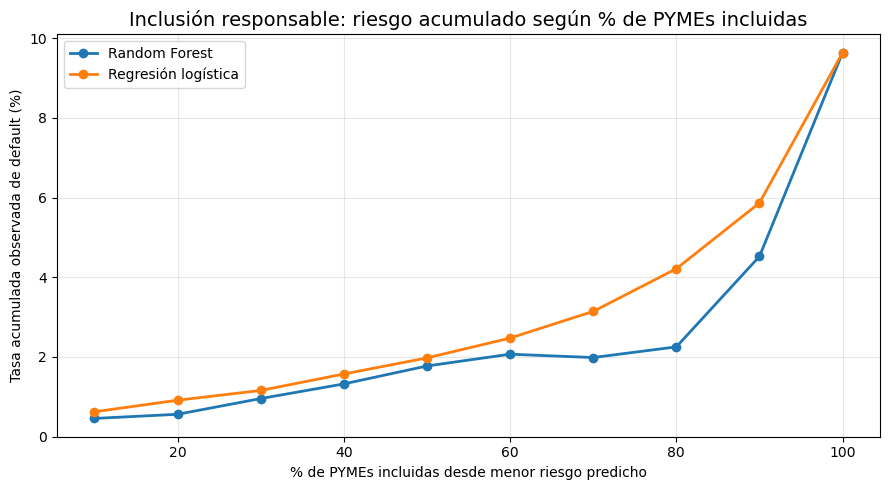

In [37]:
plt.figure(figsize=(9, 5))

for modelo in resumen_curvas["modelo"].unique():
    data = resumen_curvas[resumen_curvas["modelo"] == modelo]
    plt.plot(
        data["pct_incluido"] * 100,
        data["tasa_default_acum"] * 100,
        marker="o",
        linewidth=2,
        label=modelo
    )

plt.title("Inclusión responsable: riesgo acumulado según % de PYMEs incluidas", fontsize=14)
plt.xlabel("% de PYMEs incluidas desde menor riesgo predicho")
plt.ylabel("Tasa acumulada observada de default (%)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [39]:
df_model["businessage"].value_counts(dropna=False)

businessage
Existing, 5 or more years                 172216
Startup, Loan Funds will Open Business     62157
New, Less than 1 Year old                  42358
Unanswered                                 37773
Existing or more than 2 years old          32752
Less than 4 years old but at least 3       27631
Less than 3 years old but at least 2       23342
Less than 5 years old but at least 4       17201
Change of Ownership                         5930
NaN                                         1164
New Business or 2 years or less               18
Name: count, dtype: int64

In [40]:
test_comp["businessage"] = test_sample["businessage"].values

segmentos_jovenes = [
    "Startup, Loan Funds will Open Business",
    "New, Less than 1 year old",
    "Existing, 1 to 2 years"
]

test_comp["segmento_antiguedad"] = np.where(
    test_comp["businessage"].isin(segmentos_jovenes),
    "Empresa joven",
    "Empresa madura"
)

test_comp["segmento_antiguedad"].value_counts()

segmento_antiguedad
Empresa madura    60963
Empresa joven     11176
Name: count, dtype: int64

In [41]:
resumen_jovenes = (
    test_comp[test_comp["segmento_antiguedad"] == "Empresa joven"]
    .groupby("grupo")
    .agg(
        n=("default", "count"),
        tasa_default=("default", "mean")
    )
    .reset_index()
)

resumen_jovenes["tasa_default_pct"] = resumen_jovenes["tasa_default"] * 100
resumen_jovenes["participacion_pct"] = resumen_jovenes["n"] / resumen_jovenes["n"].sum() * 100

resumen_jovenes

,grupo,n,tasa_default,tasa_default_pct,participacion_pct
0,No seleccionado,6292,0.181659,18.165925,56.299213
1,Seleccionado por ambos,2399,0.009587,0.958733,21.465641
2,Solo Logit,2242,0.024978,2.497770,20.060845
3,Solo Random Forest,243,0.020576,2.057613,2.174302


In [44]:
# Asegurar que test_comp tenga las variables necesarias
test_comp = test_sample.copy()
test_comp["score_logit"] = proba_logit
test_comp["score_rf"] = proba_rf

# Crear segmento de empresas jóvenes
test_comp["businessage_str"] = test_comp["businessage"].astype(str)

test_comp["empresa_joven"] = test_comp["businessage_str"].str.contains(
    "Startup|Less than 1 year|1 to 2",
    case=False,
    na=False
)

test_comp["empresa_joven"].value_counts()

empresa_joven
False    59248
True     12891
Name: count, dtype: int64

In [45]:
def comparar_modelos_en_segmento(data, filtro_segmento, nombre_segmento, pct_seleccion=0.40):
    df_seg = data[filtro_segmento].copy()
    
    cut_logit = df_seg["score_logit"].quantile(pct_seleccion)
    cut_rf = df_seg["score_rf"].quantile(pct_seleccion)
    
    df_seg["seleccion_logit"] = df_seg["score_logit"] <= cut_logit
    df_seg["seleccion_rf"] = df_seg["score_rf"] <= cut_rf
    
    condiciones = [
        (df_seg["seleccion_logit"]) & (df_seg["seleccion_rf"]),
        (df_seg["seleccion_logit"]) & (~df_seg["seleccion_rf"]),
        (~df_seg["seleccion_logit"]) & (df_seg["seleccion_rf"]),
        (~df_seg["seleccion_logit"]) & (~df_seg["seleccion_rf"])
    ]
    
    opciones = [
        "Seleccionado por ambos",
        "Solo Logit",
        "Solo Random Forest",
        "No seleccionado"
    ]
    
    df_seg["grupo"] = np.select(condiciones, opciones, default="Sin clasificar")
    
    resumen = df_seg.groupby("grupo").agg(
        n=("default", "count"),
        tasa_default=("default", "mean"),
        score_logit_prom=("score_logit", "mean"),
        score_rf_prom=("score_rf", "mean")
    ).reset_index()
    
    resumen["tasa_default_pct"] = resumen["tasa_default"] * 100
    resumen["participacion_pct"] = resumen["n"] / resumen["n"].sum() * 100
    resumen["segmento"] = nombre_segmento
    
    resumen_modelos = pd.DataFrame({
        "segmento": [nombre_segmento, nombre_segmento],
        "modelo": ["Regresión logística", "Random Forest"],
        "n_seleccionados": [
            df_seg["seleccion_logit"].sum(),
            df_seg["seleccion_rf"].sum()
        ],
        "tasa_default_observada": [
            df_seg.loc[df_seg["seleccion_logit"], "default"].mean(),
            df_seg.loc[df_seg["seleccion_rf"], "default"].mean()
        ],
        "defaults_observados": [
            df_seg.loc[df_seg["seleccion_logit"], "default"].sum(),
            df_seg.loc[df_seg["seleccion_rf"], "default"].sum()
        ]
    })
    
    resumen_modelos["tasa_default_pct"] = resumen_modelos["tasa_default_observada"] * 100
    
    return df_seg, resumen, resumen_modelos

In [46]:
df_jovenes, resumen_jovenes, resumen_modelos_jovenes = comparar_modelos_en_segmento(
    data=test_comp,
    filtro_segmento=test_comp["empresa_joven"],
    nombre_segmento="Empresas jóvenes",
    pct_seleccion=0.40
)

resumen_jovenes

,grupo,n,tasa_default,score_logit_prom,score_rf_prom,tasa_default_pct,participacion_pct,segmento
0,No seleccionado,6308,0.207039,0.689232,0.519401,20.703868,48.933364,Empresas jóvenes
1,Seleccionado por ambos,3731,0.010453,0.169590,0.371389,1.045296,28.942673,Empresas jóvenes
2,Solo Logit,1426,0.031557,0.154692,0.469831,3.155680,11.061981,Empresas jóvenes
3,Solo Random Forest,1426,0.016830,0.543176,0.402209,1.683029,11.061981,Empresas jóvenes


In [47]:
resumen_modelos_jovenes

,segmento,modelo,n_seleccionados,tasa_default_observada,defaults_observados,tasa_default_pct
0,Empresas jóvenes,Regresión logística,5157,0.016289,84,1.628854
1,Empresas jóvenes,Random Forest,5157,0.012216,63,1.221640


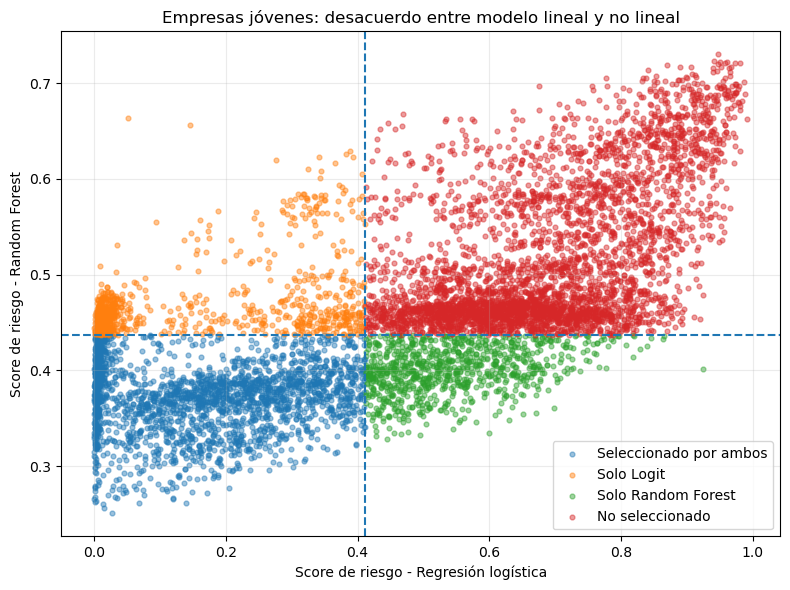

In [48]:
import matplotlib.pyplot as plt

plot_data = df_jovenes.copy()

# Para que el gráfico no quede demasiado pesado
plot_sample = plot_data.sample(
    n=min(8000, len(plot_data)),
    random_state=42
)

cut_logit_jovenes = plot_data["score_logit"].quantile(0.40)
cut_rf_jovenes = plot_data["score_rf"].quantile(0.40)

plt.figure(figsize=(8, 6))

for grupo in ["Seleccionado por ambos", "Solo Logit", "Solo Random Forest", "No seleccionado"]:
    temp = plot_sample[plot_sample["grupo"] == grupo]
    plt.scatter(
        temp["score_logit"],
        temp["score_rf"],
        s=12,
        alpha=0.45,
        label=grupo
    )

plt.axvline(cut_logit_jovenes, linestyle="--", linewidth=1.5)
plt.axhline(cut_rf_jovenes, linestyle="--", linewidth=1.5)

plt.xlabel("Score de riesgo - Regresión logística")
plt.ylabel("Score de riesgo - Random Forest")
plt.title("Empresas jóvenes: desacuerdo entre modelo lineal y no lineal")
plt.legend()
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

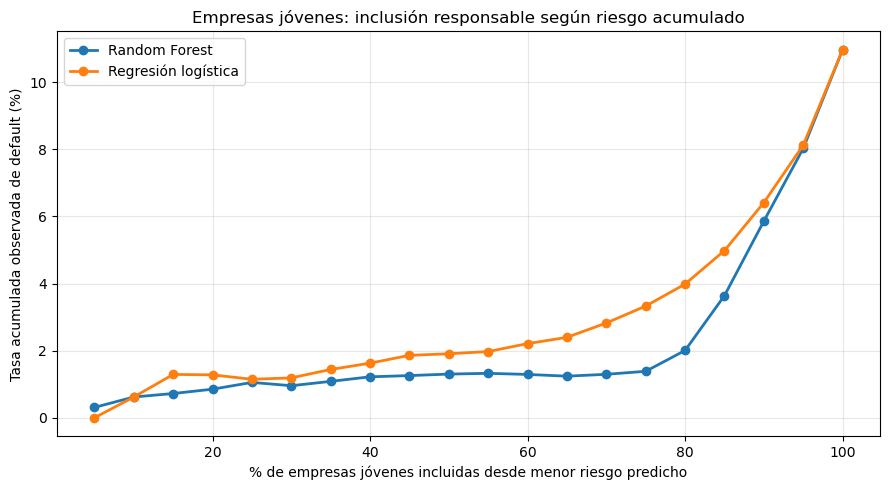

In [49]:
def curva_inclusion_segmento(df_seg, score_col, nombre_modelo):
    temp = df_seg[["default", score_col]].copy()
    temp = temp.sort_values(score_col, ascending=True).reset_index(drop=True)
    
    temp["n_acum"] = np.arange(1, len(temp) + 1)
    temp["pct_incluido"] = temp["n_acum"] / len(temp)
    temp["defaults_acum"] = temp["default"].cumsum()
    temp["tasa_default_acum"] = temp["defaults_acum"] / temp["n_acum"]
    temp["modelo"] = nombre_modelo
    
    return temp

curva_jovenes_logit = curva_inclusion_segmento(
    df_jovenes,
    "score_logit",
    "Regresión logística"
)

curva_jovenes_rf = curva_inclusion_segmento(
    df_jovenes,
    "score_rf",
    "Random Forest"
)

curvas_jovenes = pd.concat(
    [curva_jovenes_logit, curva_jovenes_rf],
    ignore_index=True
)

# Reducir a puntos cada 5% para que se vea limpio
puntos = np.arange(0.05, 1.01, 0.05)

resumen_curvas_jovenes = []

for modelo, data in curvas_jovenes.groupby("modelo"):
    for p in puntos:
        fila = data[data["pct_incluido"] <= p].tail(1)
        if len(fila) > 0:
            resumen_curvas_jovenes.append({
                "modelo": modelo,
                "pct_incluido": p,
                "tasa_default_acum": fila["tasa_default_acum"].values[0]
            })

resumen_curvas_jovenes = pd.DataFrame(resumen_curvas_jovenes)

plt.figure(figsize=(9, 5))

for modelo in resumen_curvas_jovenes["modelo"].unique():
    data = resumen_curvas_jovenes[resumen_curvas_jovenes["modelo"] == modelo]
    plt.plot(
        data["pct_incluido"] * 100,
        data["tasa_default_acum"] * 100,
        marker="o",
        linewidth=2,
        label=modelo
    )

plt.title("Empresas jóvenes: inclusión responsable según riesgo acumulado")
plt.xlabel("% de empresas jóvenes incluidas desde menor riesgo predicho")
plt.ylabel("Tasa acumulada observada de default (%)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

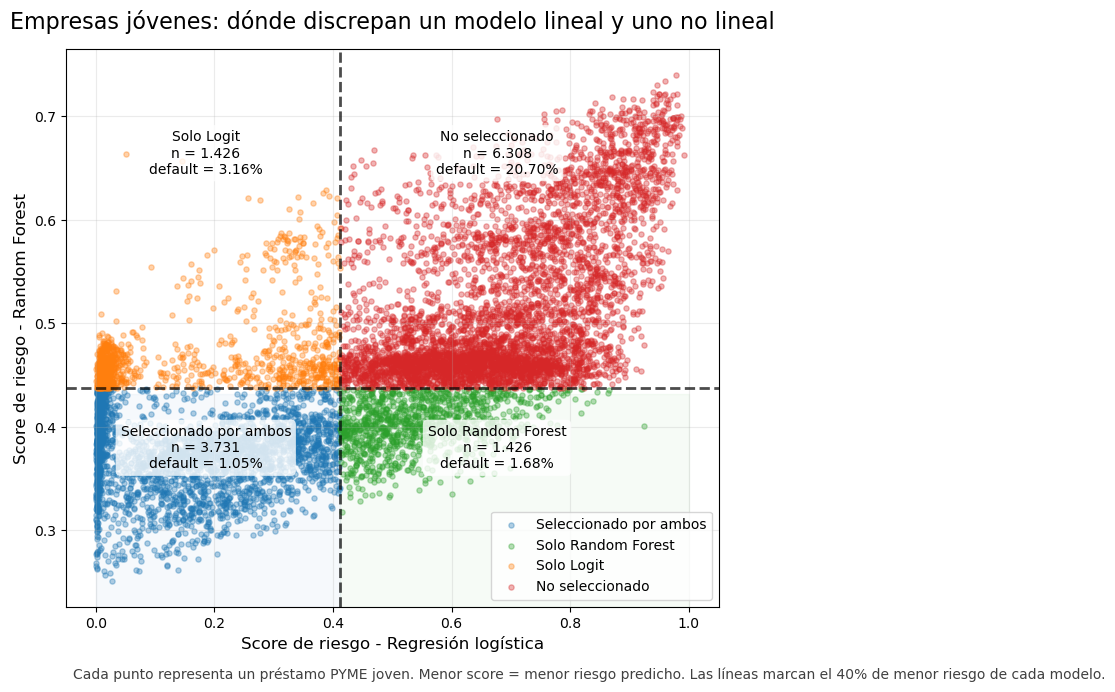

In [50]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Base del gráfico
plot_data = df_jovenes.copy()

# Muestra para no saturar visualmente
plot_sample = plot_data.sample(
    n=min(10000, len(plot_data)),
    random_state=42
)

# Cortes del 40% menor riesgo dentro de empresas jóvenes
cut_logit = plot_data["score_logit"].quantile(0.40)
cut_rf = plot_data["score_rf"].quantile(0.40)

# Resumen por grupo para anotaciones
resumen_plot = plot_data.groupby("grupo").agg(
    n=("default", "count"),
    default_pct=("default", lambda x: x.mean() * 100)
).reset_index()

resumen_dict = resumen_plot.set_index("grupo").to_dict("index")

# Colores editoriales
colores = {
    "Seleccionado por ambos": "#1f77b4",
    "Solo Logit": "#ff7f0e",
    "Solo Random Forest": "#2ca02c",
    "No seleccionado": "#d62728"
}

fig, ax = plt.subplots(figsize=(10, 7))

# Fondos suaves por cuadrante
ax.axvspan(0, cut_logit, ymin=0, ymax=(cut_rf - plot_data["score_rf"].min()) / (plot_data["score_rf"].max() - plot_data["score_rf"].min()), 
           alpha=0.04, color=colores["Seleccionado por ambos"])
ax.axvspan(cut_logit, 1, ymin=0, ymax=(cut_rf - plot_data["score_rf"].min()) / (plot_data["score_rf"].max() - plot_data["score_rf"].min()), 
           alpha=0.04, color=colores["Solo Random Forest"])

# Puntos
orden_grupos = [
    "Seleccionado por ambos",
    "Solo Random Forest",
    "Solo Logit",
    "No seleccionado"
]

for grupo in orden_grupos:
    temp = plot_sample[plot_sample["grupo"] == grupo]
    ax.scatter(
        temp["score_logit"],
        temp["score_rf"],
        s=14,
        alpha=0.35,
        label=grupo,
        color=colores[grupo]
    )

# Líneas de corte
ax.axvline(cut_logit, linestyle="--", linewidth=2, color="black", alpha=0.7)
ax.axhline(cut_rf, linestyle="--", linewidth=2, color="black", alpha=0.7)

# Función para anotar cuadrantes
def texto_grupo(grupo):
    if grupo in resumen_dict:
        n = resumen_dict[grupo]["n"]
        d = resumen_dict[grupo]["default_pct"]
        return f"{grupo}\nn = {n:,.0f}\ndefault = {d:.2f}%".replace(",", ".")
    return grupo

# Posiciones de etiquetas dentro de cuadrantes
x_min, x_max = ax.get_xlim()
y_min, y_max = ax.get_ylim()

ax.text(
    cut_logit * 0.45,
    cut_rf * 0.92,
    texto_grupo("Seleccionado por ambos"),
    fontsize=10,
    ha="center",
    va="top",
    bbox=dict(boxstyle="round,pad=0.35", facecolor="white", alpha=0.8, edgecolor="none")
)

ax.text(
    cut_logit + (1 - cut_logit) * 0.45,
    cut_rf * 0.92,
    texto_grupo("Solo Random Forest"),
    fontsize=10,
    ha="center",
    va="top",
    bbox=dict(boxstyle="round,pad=0.35", facecolor="white", alpha=0.8, edgecolor="none")
)

ax.text(
    cut_logit * 0.45,
    cut_rf + (plot_data["score_rf"].max() - cut_rf) * 0.75,
    texto_grupo("Solo Logit"),
    fontsize=10,
    ha="center",
    va="center",
    bbox=dict(boxstyle="round,pad=0.35", facecolor="white", alpha=0.8, edgecolor="none")
)

ax.text(
    cut_logit + (1 - cut_logit) * 0.45,
    cut_rf + (plot_data["score_rf"].max() - cut_rf) * 0.75,
    texto_grupo("No seleccionado"),
    fontsize=10,
    ha="center",
    va="center",
    bbox=dict(boxstyle="round,pad=0.35", facecolor="white", alpha=0.8, edgecolor="none")
)

# Títulos y ejes
ax.set_title(
    "Empresas jóvenes: dónde discrepan un modelo lineal y uno no lineal",
    fontsize=16,
    pad=15
)

ax.set_xlabel("Score de riesgo - Regresión logística", fontsize=12)
ax.set_ylabel("Score de riesgo - Random Forest", fontsize=12)

# Nota metodológica
ax.text(
    0.01,
    -0.13,
    "Cada punto representa un préstamo PYME joven. Menor score = menor riesgo predicho. "
    "Las líneas marcan el 40% de menor riesgo de cada modelo.",
    transform=ax.transAxes,
    fontsize=10,
    alpha=0.75
)

ax.grid(True, alpha=0.25)
ax.legend(loc="lower right", frameon=True)
plt.tight_layout()

plt.show()

In [51]:
resumen_jovenes


,grupo,n,tasa_default,score_logit_prom,score_rf_prom,tasa_default_pct,participacion_pct,segmento
0,No seleccionado,6308,0.207039,0.689232,0.519401,20.703868,48.933364,Empresas jóvenes
1,Seleccionado por ambos,3731,0.010453,0.169590,0.371389,1.045296,28.942673,Empresas jóvenes
2,Solo Logit,1426,0.031557,0.154692,0.469831,3.155680,11.061981,Empresas jóvenes
3,Solo Random Forest,1426,0.016830,0.543176,0.402209,1.683029,11.061981,Empresas jóvenes


In [52]:
resumen_modelos_jovenes


,segmento,modelo,n_seleccionados,tasa_default_observada,defaults_observados,tasa_default_pct
0,Empresas jóvenes,Regresión logística,5157,0.016289,84,1.628854
1,Empresas jóvenes,Random Forest,5157,0.012216,63,1.221640


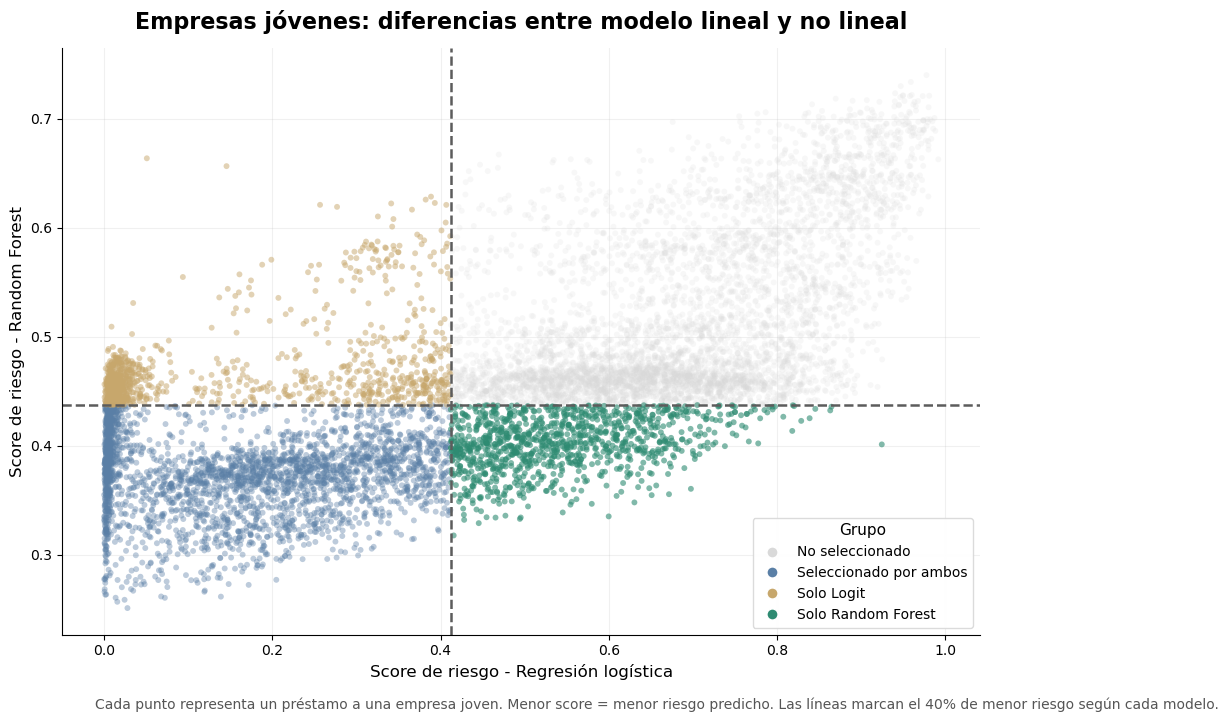

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# =========================
# 1. Preparar datos
# =========================

plot_data = df_jovenes.copy()

plot_sample = plot_data.sample(
    n=min(10000, len(plot_data)),
    random_state=42
)

cut_logit = plot_data["score_logit"].quantile(0.40)
cut_rf = plot_data["score_rf"].quantile(0.40)

# =========================
# 2. Paleta y estilo
# =========================

colores = {
    "No seleccionado": "#D9D9D9",
    "Seleccionado por ambos": "#5A7FA6",
    "Solo Logit": "#C7A76C",
    "Solo Random Forest": "#2E8B72"
}

alphas = {
    "No seleccionado": 0.20,
    "Seleccionado por ambos": 0.40,
    "Solo Logit": 0.50,
    "Solo Random Forest": 0.60
}

orden_grupos = [
    "No seleccionado",
    "Seleccionado por ambos",
    "Solo Logit",
    "Solo Random Forest"
]

# =========================
# 3. Crear gráfico
# =========================

fig, ax = plt.subplots(figsize=(10, 7))

for grupo in orden_grupos:
    temp = plot_sample[plot_sample["grupo"] == grupo]
    ax.scatter(
        temp["score_logit"],
        temp["score_rf"],
        s=18,
        alpha=alphas[grupo],
        color=colores[grupo],
        edgecolors="none"
    )

# Líneas de corte
ax.axvline(
    cut_logit,
    linestyle="--",
    linewidth=1.8,
    color="#5C5C5C"
)

ax.axhline(
    cut_rf,
    linestyle="--",
    linewidth=1.8,
    color="#5C5C5C"
)

# =========================
# 4. Formato del gráfico
# =========================

ax.set_title(
    "Empresas jóvenes: diferencias entre modelo lineal y no lineal",
    fontsize=16,
    fontweight="semibold",
    pad=14
)

ax.set_xlabel("Score de riesgo - Regresión logística", fontsize=12)
ax.set_ylabel("Score de riesgo - Random Forest", fontsize=12)

ax.grid(True, alpha=0.18, linewidth=0.8)
ax.set_axisbelow(True)

# Quitar bordes para look limpio
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# =========================
# 5. Leyenda personalizada
# =========================

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='No seleccionado',
           markerfacecolor=colores["No seleccionado"], markersize=8),
    Line2D([0], [0], marker='o', color='w', label='Seleccionado por ambos',
           markerfacecolor=colores["Seleccionado por ambos"], markersize=8),
    Line2D([0], [0], marker='o', color='w', label='Solo Logit',
           markerfacecolor=colores["Solo Logit"], markersize=8),
    Line2D([0], [0], marker='o', color='w', label='Solo Random Forest',
           markerfacecolor=colores["Solo Random Forest"], markersize=8)
]

legend = ax.legend(
    handles=legend_elements,
    title="Grupo",
    loc="lower right",
    frameon=True,
    facecolor="white",
    edgecolor="#D9D9D9",
    framealpha=0.95
)

legend.get_title().set_fontsize(11)

# =========================
# 6. Nota al pie
# =========================

plt.figtext(
    0.10,
    -0.02,
    "Cada punto representa un préstamo a una empresa joven. "
    "Menor score = menor riesgo predicho. "
    "Las líneas marcan el 40% de menor riesgo según cada modelo.",
    ha="left",
    fontsize=10,
    color="#555555"
)

plt.tight_layout()

plt.savefig(
    "grafico_desacuerdo_modelos_empresas_jovenes_mejorado.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()